In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from matplotlib.transforms import offset_copy
from matplotlib import colors
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
%run LittRuP__import_functions.ipynb

In [3]:
# chemins vers fichiers Data et Images

BASE_DIR = Path.cwd()
DAT_DIR = BASE_DIR / "Data"
IMG_DIR = BASE_DIR / "Images"

In [4]:
# import matrice étendue

matrix_all_extended = pd.read_csv(DAT_DIR / "LittRu_matrix_all_extended.csv", sep=',', header=0)

In [5]:
# indique que les thèmes sont toutes les colonnes situées après "CutOff"

theme_cols = matrix_all_extended.columns[
    matrix_all_extended.columns.get_loc("CutOff") + 1:
]

In [6]:
# matrice des thèmes 0/1

matrix_themes = matrix_all_extended[theme_cols]

In [9]:
# liste des thèmes

the_themes = matrix_themes.columns.values.tolist()

In [10]:
# liste des oeuvres

the_works = matrix_all_extended["Works"].unique().tolist()

**ACP des oeuvres sur la matrice initiale**

In [25]:
# en partant de "matrix_all_extended" ,on obtient "matrix_works_profile"
# où l'on a les oeuvres en lignes et les thèmes en colonnes.
#
# chaque oeuvre est caractérisée par l’ensemble des thèmes qui sont présents dans l'oeuvre.
# Donc deux oeuvres sont proches dans cette ACP si elles ont des profils d’apparition comparables dans les thèmes.


In [14]:
matrix_works_profile = (
    matrix_all_extended
    .set_index("Works")[the_themes]
)
matrix_works_profile.index.name = "Works"
matrix_works_profile.columns.name = "Themes"


In [13]:
matrix_works_profile.head()

Themes,Amour,Apprentissage,Argent,Armée,Art,Bonheur,Campagne,Camps,Capitalisme,Communisme,...,Servage,Socialisme,Société,Solitude,Souffrance,Traditions,Travail,Vagabondage,Ville,Violence
Works,,,,,,,,,,,,,,,,,,,,,
Et l'Acier fut trempé,0,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
L'Adolescent,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
L'Affaire des Artamonov,0,0,1,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
Les Ames mortes,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Anna Karénine,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


**ACP des oeuvres (variances des axes)**

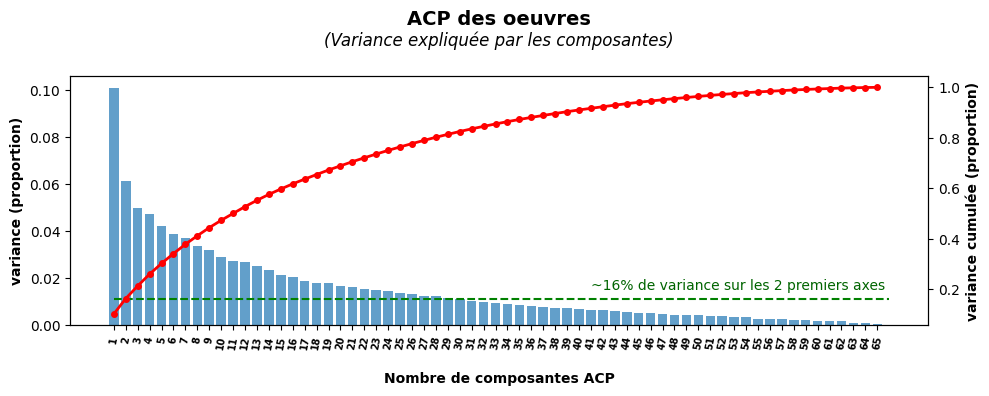

In [15]:
X_tot = matrix_works_profile.astype(float)

max_comp = min(X_tot.shape[0] - 1, X_tot.shape[1])

pca_tot = PCA(n_components = max_comp)

pca_tot.fit(X_tot)

var = pca_tot.explained_variance_ratio_

fig, ax1 = plt.subplots(figsize=(10, 4))

xs = range(max_comp)
labels_xs=[i+1 for i in list(xs)]
ax1.bar(x=xs, height=var, alpha=0.7, label="variance par axe (%)")
ax1.set_xlabel("\nNombre de composantes ACP", fontweight="bold")
ax1.set_ylabel("variance (proportion)", fontweight="bold")
ax1.set_xticks(xs, labels_xs, fontsize=7, fontweight="bold", rotation=80)

cum_var = np.cumsum(var)

ax2 = ax1.twinx()
ax2.plot(xs, cum_var, color="red", marker="o", ms=4, linewidth=2, label="variance cumulée")
ax2.set_ylabel("variance cumulée (proportion)", fontweight="bold")

ax2.hlines(
    y=0.16,
    xmin=0,
    xmax=65,
    color="green",
    linestyle="--",
    linewidth=1.5,
    zorder=0
)
trans = offset_copy(ax2.transData, fig=fig, x=0, y=5, units='points')

ax2.text(
    40,
    0.16,
    "~16% de variance sur les 2 premiers axes",
    transform=trans,
    rotation=0,
    va="bottom",
    fontsize=10,
    color="darkgreen"
)

fig.tight_layout(rect=[0, 0, 1, 0.85])

titres(fig, ax1,
    t1="ACP des oeuvres", y1=37,
    t2="(Variance expliquée par les composantes)", y2=22,
    t3=" ", y3=7
)

fig.savefig(
    IMG_DIR / "oeuvres_ACP__variances_expliquées.png", 
    dpi=300,
    bbox_inches="tight")

plt.show()

**Variance sur les 2 premières composantes**

In [16]:
var[0] + var[1]

np.float64(0.16238734616190484)

**ACP sur les axes 1 et 2**

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


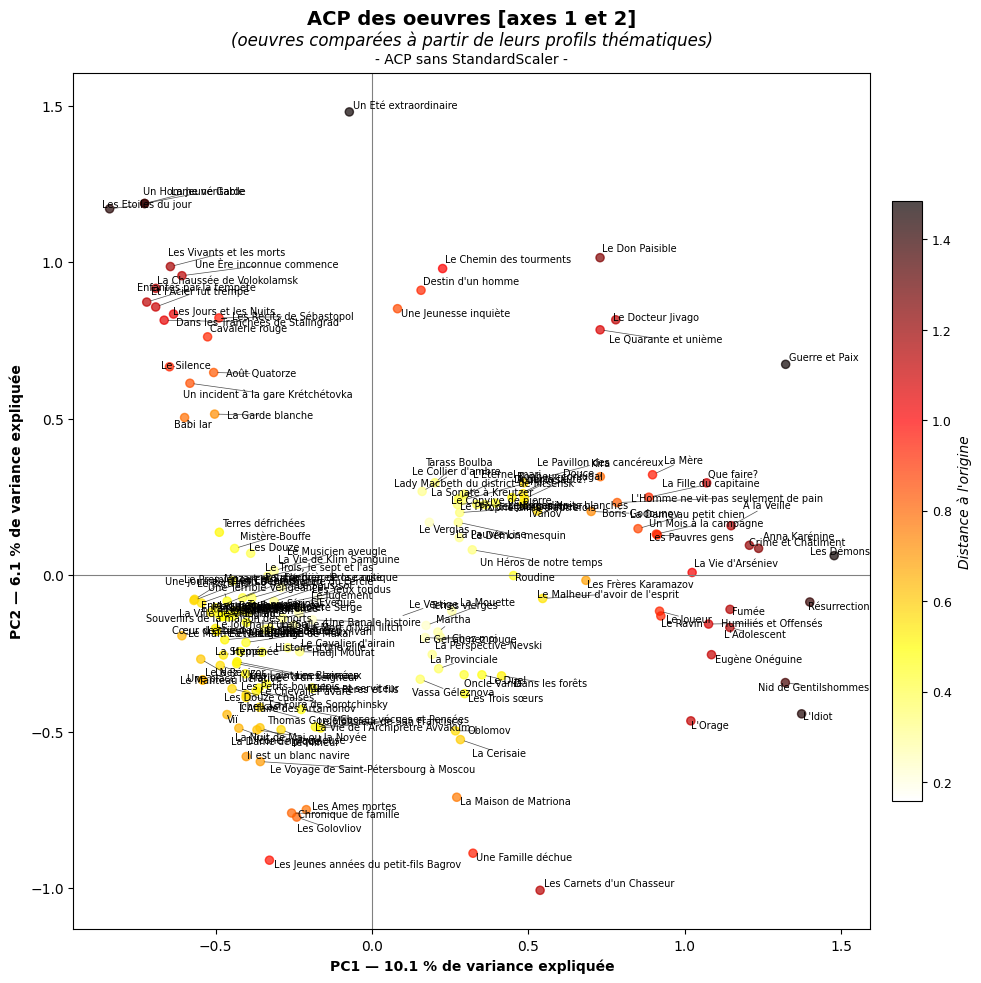

In [17]:
X = matrix_works_profile.astype(float)

# réaliser la PCA

pca = PCA(n_components=2)

# contient les coordonnées sur les deux axes PCA

row_coords = pca.fit_transform(X)

# Pourcentage de variance expliqué

PC1, PC2 = pca.explained_variance_ratio_

# coordonnées dans le plan ACP

works_coords = pd.DataFrame(
    row_coords,
    columns=["PC1", "PC2"],
    index=X.index
)

# distance à l'origine : mesure visuelle de contribution/importance sur le plan

works_coords["dist_origin"] = np.sqrt(
    works_coords["PC1"]**2 + works_coords["PC2"]**2
)

import io
import contextlib
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(10, 10))

scatter = ax.scatter(
    works_coords["PC1"],
    works_coords["PC2"],
    c=works_coords["dist_origin"],
    cmap="hot_r",
    s=35,
    alpha=0.7,
    zorder=1
)

texts = []

for works in works_coords.index:
    texts.append(
        ax.text(
            works_coords.loc[works, "PC1"],
            works_coords.loc[works, "PC2"],
            works,
            fontsize=7,
            color="black",
            zorder=3
        )
    )

with contextlib.redirect_stdout(io.StringIO()):
    adjust_text(
        texts,
        ax=ax,
        x=works_coords["PC1"],
        y=works_coords["PC2"],
        expand_text=(1.2, 1.4),
        expand_points=(1.4, 1.6),
        force_text=(0.4, 0.6),
        force_points=(0.3, 0.5),
        arrowprops=dict(
            arrowstyle="-",
            color="black",
            lw=0.5,
            alpha=0.7,
            shrinkA=8,
            shrinkB=3
        )
    )

ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(0, color="grey", linewidth=0.8)

ax.set_xlabel(f"PC1 — {PC1*100:.1f} % de variance expliquée", fontsize=10, fontweight='bold')
ax.set_ylabel(f"PC2 — {PC2*100:.1f} % de variance expliquée", fontsize=10, fontweight='bold')

ax.set_aspect("equal")

cbar = plt.colorbar(
    scatter,
    ax=ax,
    shrink=0.70,     # raccourcit la barre à x % de sa hauteur
    fraction=0.045,  # barre plus mince
    pad=0.025        # rapproche légèrement la barre du graphique
)
cbar.ax.tick_params(labelsize=9)
cbar.set_label("Distance à l'origine", fontsize=10, fontstyle="italic")

fig.tight_layout(rect=[0, 0, 1, 0.93])

titres(fig, ax,
    t1="ACP des oeuvres [axes 1 et 2]", y1=35,
    t2="(oeuvres comparées à partir de leurs profils thématiques)", y2=20,
    t3="- ACP sans StandardScaler -", y3=7
)

fig.savefig(
    IMG_DIR / "oeuvres_ACP__PC1_PC2.png", 
    dpi=300,
    bbox_inches="tight")

plt.show()

**Identification des oeuvres excentrées**

In [18]:
works_coords["frequence"] = matrix_works_profile.sum(axis=1)

works_coords.sort_values("dist_origin", ascending=False).head(15)

,PC1,PC2,dist_origin,frequence
Works,,,,
Guerre et Paix,1.322156,0.673993,1.484036,10
Un Eté extraordinaire,-0.072291,1.480655,1.482419,5
Les Démons,1.477225,0.062529,1.478548,9
L'Idiot,1.373223,-0.443037,1.442922,8
Les Etoiles du jour,-0.838356,1.171013,1.440178,5
Résurrection,1.399286,-0.085597,1.401902,9
Un Homme véritable,-0.726521,1.188047,1.392583,4
La Jeune Garde,-0.726521,1.188047,1.392583,4
Nid de Gentilshommes,1.321177,-0.343150,1.365013,7
